# Chapter 12 example: submodularity and the MAP-LP gap

The local-polytope MAP relaxation is exact for broad submodular classes, but can be fractional for frustrated interactions. We compare two binary three-node models using exactly the same LP.

The LP variables are node beliefs $b_i(x_i)$ and edge beliefs $b_{ij}(x_i,x_j)$, constrained only by normalization, nonnegativity, and local marginal consistency.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
def map_lp_triangle(J):
    nodes=range(3); edges=[(0,1),(1,2),(0,2)]; vals=[-1,1]
    # variables: 3*2 node + 3*4 edge = 18
    idx={}; k=0
    for i in nodes:
      for x in vals: idx=('n',i,x)
    var_index={}; k=0
    for i in nodes:
      for x in vals: var_index[('n',i,x)]=k; k+=1
    for e in edges:
      for xi in vals:
       for xj in vals: var_index[('e',e,xi,xj)]=k; k+=1
    c=np.zeros(k)
    for e in edges:
      for xi in vals:
       for xj in vals: c[var_index[('e',e,xi,xj)]]=-J[e]*xi*xj
    A=[]; b=[]
    for i in nodes:
      row=np.zeros(k)
      for x in vals: row[var_index[('n',i,x)]]=1
      A.append(row); b.append(1)
    for e in edges:
      i,j=e
      for xi in vals:
       row=np.zeros(k); row[var_index[('n',i,xi)]]=-1
       for xj in vals: row[var_index[('e',e,xi,xj)]]+=1
       A.append(row); b.append(0)
      for xj in vals:
       row=np.zeros(k); row[var_index[('n',j,xj)]]=-1
       for xi in vals: row[var_index[('e',e,xi,xj)]]+=1
       A.append(row); b.append(0)
    res=linprog(c,A_eq=np.array(A),b_eq=np.array(b),bounds=(0,None),method='highs')
    return res,var_index
edges=[(0,1),(1,2),(0,2)]
models={'attractive':{e:1.0 for e in edges},'frustrated':{(0,1):1.,(1,2):1.,(0,2):-1.}}
states=np.array(list(product([-1,1],repeat=3)))
rows=[]
for name,J in models.items():
  E=np.array([-sum(J[e]*x[e[0]]*x[e[1]] for e in edges) for x in states]); exact=E.min(); res,vi=map_lp_triangle(J); rows.append((name,exact,res.fun,exact-res.fun))
df=pd.DataFrame(rows,columns=['model','exact MAP energy','MAP-LP energy','integrality gap']); display(df)

,model,exact MAP energy,MAP-LP energy,integrality gap
0,attractive,-3.0,-3.0,0.0
1,frustrated,-1.0,-3.0,2.0


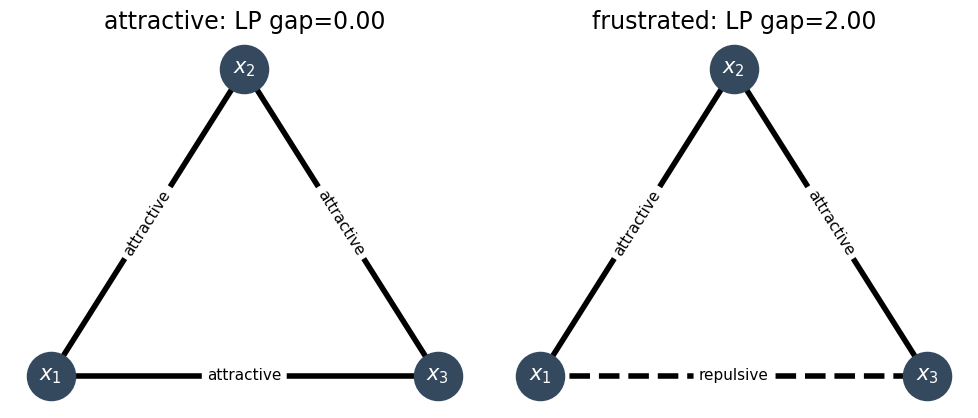

In [3]:
fig,axes=plt.subplots(1,2,figsize=(10,4.4)); pos={0:(0,0),1:(1,1),2:(2,0)}
for ax,(name,J) in zip(axes,models.items()):
 G=nx.Graph(); G.add_edges_from(edges); nx.draw_networkx_nodes(G,pos,node_color=NODE_COLOR,node_size=1200,ax=ax); nx.draw_networkx_labels(G,pos,labels={i:rf'$x_{i+1}$' for i in range(3)},font_color='white',font_size=15,ax=ax)
 for e in edges:
  style='solid' if J[e]>0 else 'dashed'; nx.draw_networkx_edges(G,pos,edgelist=[e],width=4,style=style,ax=ax)
 nx.draw_networkx_edge_labels(G,pos,edge_labels={e:('attractive' if J[e]>0 else 'repulsive') for e in edges},font_size=11,ax=ax); ax.set_title(f'{name}: LP gap={df.loc[df.model==name,"integrality gap"].iloc[0]:.2f}'); ax.axis('off')
fig.tight_layout(); save_figure(fig,'ch12_01_attractive_vs_frustrated'); plt.show()

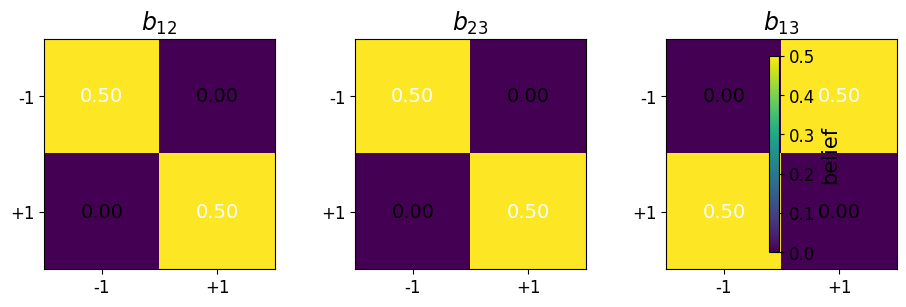

In [4]:
res,vi=map_lp_triangle(models['frustrated']); vals=[-1,1]; edge_b=[]
for e in edges:
    M=np.array([[res.x[vi[('e',e,xi,xj)]] for xj in vals] for xi in vals]); edge_b.append(M)
fig,axes=plt.subplots(1,3,figsize=(11,3.4));
for ax,e,M in zip(axes,edges,edge_b):
 im=ax.imshow(M,vmin=0,vmax=.5); ax.set_xticks([0,1],['-1','+1']); ax.set_yticks([0,1],['-1','+1']); ax.set_title(rf'$b_{{{e[0]+1}{e[1]+1}}}$')
 for i in range(2):
  for j in range(2): ax.text(j,i,f'{M[i,j]:.2f}',ha='center',va='center',color='white' if M[i,j]>.25 else 'black')
fig.colorbar(im,ax=axes.ravel().tolist(),label='belief',shrink=.75); fig.subplots_adjust(right=.9,wspace=.35); save_figure(fig,'ch12_01_fractional_edge_beliefs'); plt.show()

## Exercises

1. Change the sign of one more coupling. When does frustration disappear?
2. Add arbitrary node fields to the attractive model and test whether the LP remains tight.
3. **Challenge.** Generalize the LP builder to a five-cycle and search automatically for instances with a nonzero integrality gap.